In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import numpy as np
import random
from PIL import Image , ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten , Dropout , Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [31]:
train_dir = '/content/drive/MyDrive/Brain-Tumor-MRI/MRI-Dataset/Training'
tes_dir = '/content/drive/MyDrive/Brain-Tumor-MRI/MRI-Dataset/Testing'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths,train_labels)

test_paths = []
test_labels = []
for label in os.listdir(tes_dir):
  # print(os.path.join(tes_dir,label))
  for image in os.listdir(os.path.join(tes_dir,label)):
    test_paths.append(os.path.join(tes_dir,label,image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths,test_labels)


[3322, 3162, 459, 1821, 2794, 3976, 4012, 1539, 4968, 506]


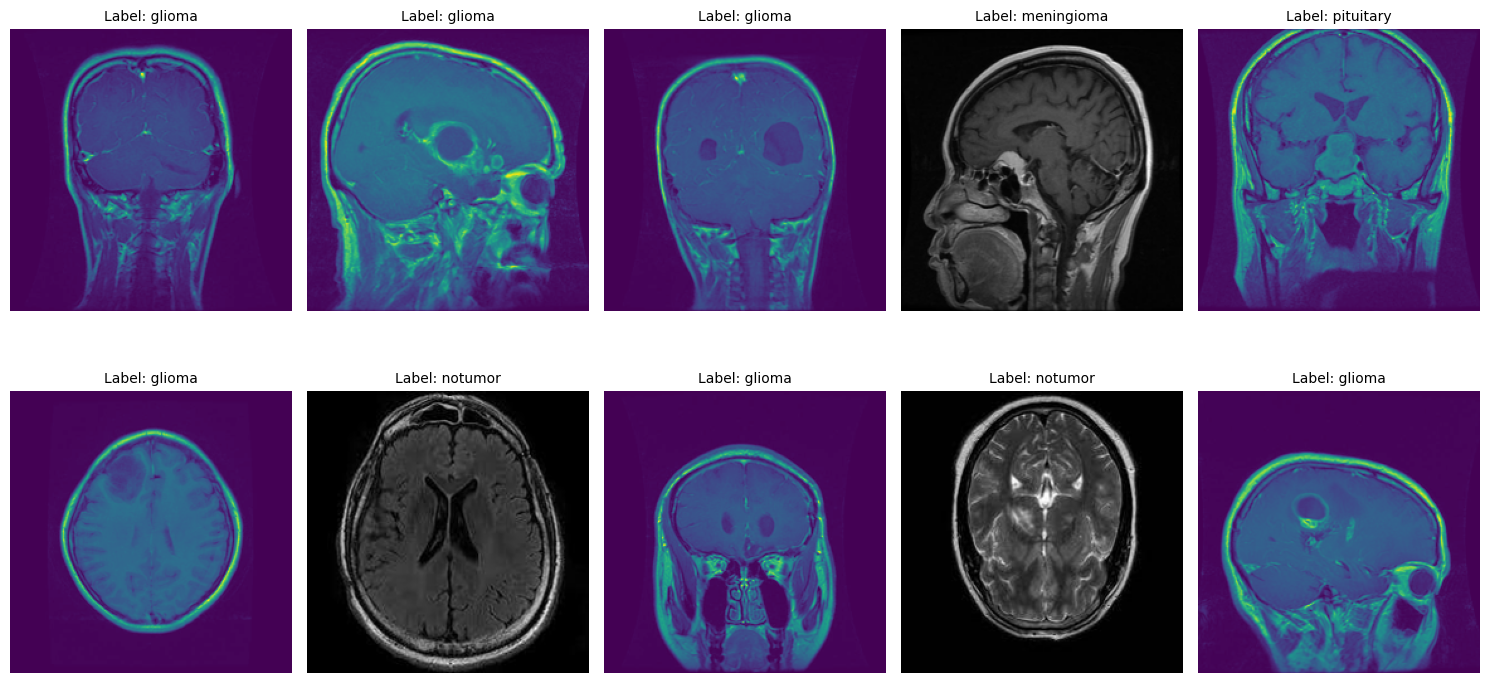

In [32]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random_indices = random.sample(range(len(train_paths)),10)
print(random_indices)

fig , axes = plt.subplots(2,5,figsize=(15,8))
axes = axes.ravel();

for i,index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((224,224))

  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(f"Label: {train_labels[index]}",fontsize=10)


plt.tight_layout()
plt.show()

In [33]:
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  enhancer = ImageEnhance.Brightness(image)
  factor = random.uniform(0.8,1.2)
  image = enhancer.enhance(factor)
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  image = np.array(image) / 255.0
  return image

# Encoding labels (convert label names to integers)
def encode_label(labels):
    # Define the fixed order of unique labels
    unique_labels = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Use the same order as class_labels
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)


def open_images(paths):
  images = []
  for path in paths:
    img = load_img(path,target_size=(128,128))
    img = augment_image(img)
    images.append(img)
  return np.array(images)


def datagen(paths, labels, batch_size,epochs=1):
  for _ in range(epochs):
    for i in range(0,len(paths),batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]

      batch_labels=encode_label(batch_labels)
      yield batch_images , batch_labels

In [34]:
IMAGE_SIZE = 128
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(IMAGE_SIZE,IMAGE_SIZE,3))

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable=True
base_model.layers[-3].trainable=True
base_model.layers[-4].trainable=True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))


model.compile(optimizer=Adam(learning_rate=0.0001),
               loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 5

history = model.fit(datagen(train_paths,train_labels,batch_size=batch_size,epochs=epochs),
                    epochs=epochs,steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2957s 10s/step - loss: 0.6187 - sparse_categorical_accuracy: 0.7592
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - loss: 0.2432 - sparse_categorical_accuracy: 0.9107
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - loss: 0.1728 - sparse_categorical_accuracy: 0.9357
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 0.1169 - sparse_categorical_accuracy: 0.9528
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 0.0715 - sparse_categorical_accuracy: 0.9727


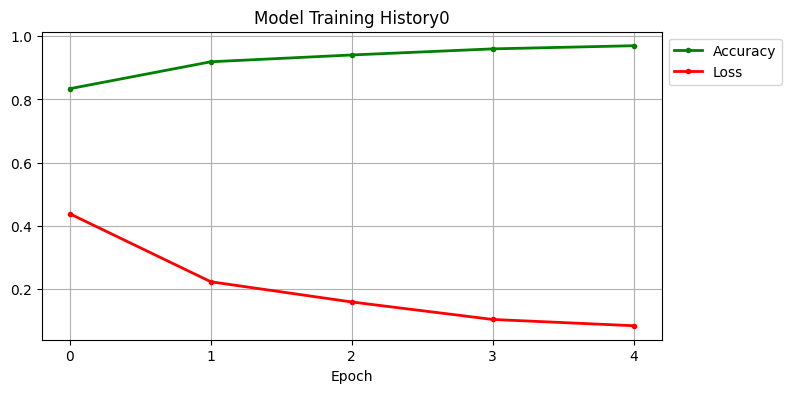

In [35]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2)
plt.plot(history.history['loss'],'.r-',linewidth=2)
plt.title('Model Training History0')
plt.xlabel('Epoch')
plt.xticks([x for x  in range(epochs)])
plt.legend(['Accuracy','Loss'],loc='upper left',bbox_to_anchor=(1,1))
plt.show()

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)


test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       300
           1       0.88      0.92      0.90       306
           2       1.00      0.99      0.99       405
           3       0.93      0.99      0.96       300

    accuracy                           0.95      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.95      0.95      0.95      1311



Confusion Matrix:
[[260  35   0   5]
 [  7 282   0  17]
 [  3   1 400   1]
 [  0   2   0 298]]


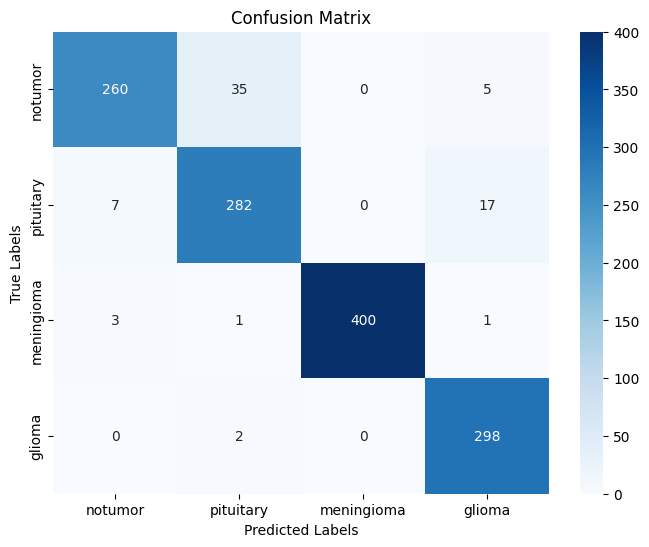

In [37]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [38]:
# Save the entire model
model.save('model.h5')

In [39]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [40]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f})")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))